=== ЗАВДАННЯ 1: ЛІНІЙНА РЕГРЕСІЯ ===
Датасет 'Real Estate' завантажено успішно!


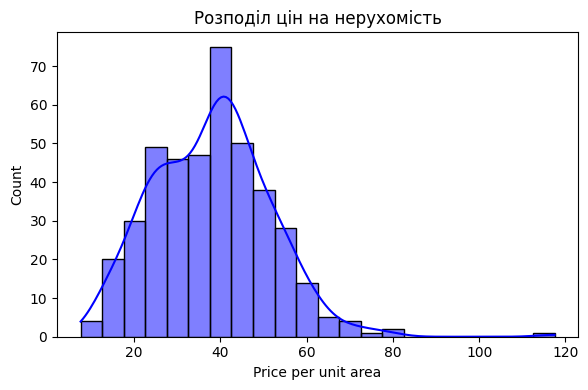


Вагові коефіцієнти моделі:
                                  Feature      Weight
0                     X1 transaction date    5.146227
1                            X2 house age   -0.269695
2  X3 distance to the nearest MRT station   -0.004487
3         X4 number of convenience stores    1.133277
4                             X5 latitude  225.472976
5                            X6 longitude  -12.423601
Вільний коефіцієнт (Intercept): -14437.10

Перші 10 передбачень: 
[47.1689389  47.82573429 48.79677789 48.36964101 46.13886467 31.13584564
 38.61587363 46.85211217  9.16603868 34.77290915]

Порівняння передбачень та реальних значень (перші 5):
   Prediction  Ground truth
0   47.168939          37.9
1   47.825734          42.2
2   48.796778          47.3
3   48.369641          54.8
4   46.138865          43.1


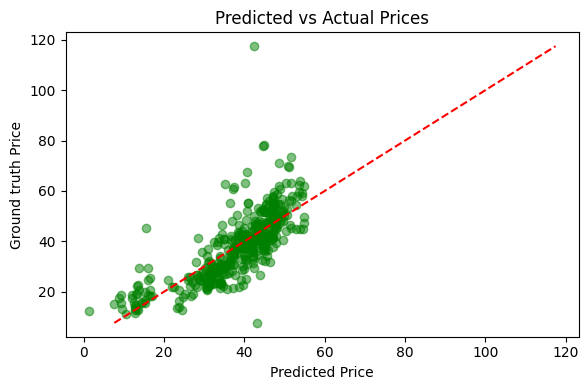

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore') # Вимикаємо попередження для чистого виводу

# Для відображення графіків усередині Notebook [cite: 983]
%matplotlib inline

print("=== ЗАВДАННЯ 1: ЛІНІЙНА РЕГРЕСІЯ ===")

# 1. Завантаження та огляд даних [cite: 995-996]
try:
    df_reg = pd.read_csv('Real estate.csv')
    print("Датасет 'Real Estate' завантажено успішно!")
except FileNotFoundError:
    print("Помилка: файл 'Real estate.csv' не знайдено.")

# Видаляємо колонку 'No' (порядковий номер), бо вона не є ознакою
df_reg = df_reg.drop('No', axis=1)

# Визначаємо ознаки (X) та цільову змінну (y)
X_reg = df_reg.drop('Y house price of unit area', axis=1)
y_reg = df_reg['Y house price of unit area']

# 2. Візуальний аналіз цільової змінної [cite: 999-1004]
plt.figure(figsize=(6, 4))
# Використовуємо сучасний histplot замість застарілого distplot
sns.histplot(y_reg, kde=True, color='blue')
plt.xlabel('Price per unit area')
plt.ylabel('Count')
plt.title('Розподіл цін на нерухомість')
plt.tight_layout()
plt.show()

# 3. Навчання моделі лінійної регресії [cite: 1006-1012]
linear_regression = LinearRegression()
model_reg = linear_regression.fit(X_reg, y_reg) # Метод fit для навчання моделі [cite: 1008]

# 4. Аналіз вагових коефіцієнтів [cite: 1014-1023]
# Лінійна регресія розкидує вагові коефіцієнти для оцінки вкладу кожної ознаки [cite: 1014]
feature_weight_df = pd.DataFrame(list(zip(X_reg.columns, model_reg.coef_)))
feature_weight_df.columns = ['Feature', 'Weight']
print("\nВагові коефіцієнти моделі:")
print(feature_weight_df)
print(f"Вільний коефіцієнт (Intercept): {model_reg.intercept_:.2f}") # [cite: 1028]

# 5. Виконання передбачень [cite: 1037-1039]
predicted_reg = model_reg.predict(X_reg)
print(f"\nПерші 10 передбачень: \n{predicted_reg[:10]}")

# 6. Порівняння передбачень з реальними даними у таблиці [cite: 1040-1043]
predictions_ground_truth_df = pd.DataFrame(list(zip(predicted_reg, y_reg)))
predictions_ground_truth_df.columns = ['Prediction', 'Ground truth']
print("\nПорівняння передбачень та реальних значень (перші 5):")
print(predictions_ground_truth_df.head())

# 7. Графічне відображення якості передбачень [cite: 1044-1050]
plt.figure(figsize=(6, 4))
plt.scatter(predicted_reg, y_reg, alpha=0.5, color='green')
plt.xlabel('Predicted Price')
plt.ylabel('Ground truth Price')
plt.title('Predicted vs Actual Prices')
# Лінія ідеального передбачення [cite: 1051]
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], color="red", linestyle='--')
plt.tight_layout()
plt.show()


=== ЗАВДАННЯ 2: КЛАСИФІКАЦІЯ ===
Датасет 'Diabetes' завантажено успішно!


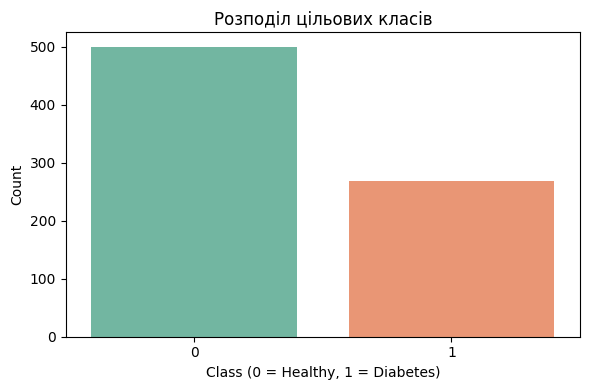


Коефіцієнти моделі для кожної ознаки:
                    Feature  Coefficient
0               Pregnancies     0.122501
1                   Glucose     0.035110
2             BloodPressure    -0.013299
3             SkinThickness     0.000781
4                   Insulin    -0.001174
5                       BMI     0.089644
6  DiabetesPedigreeFunction     0.867803
7                       Age     0.014985

Передбачені класи (перші 10): 
[1 0 1 0 1 0 0 1 1 0]

Ймовірності належності до класів [P(Class=0), P(Class=1)] (перші 5): 
[[0.28057388 0.71942612]
 [0.95070638 0.04929362]
 [0.20742742 0.79257258]
 [0.95726427 0.04273573]
 [0.11035672 0.88964328]]

Accuracy (Точність моделі): 0.7812


In [2]:
from sklearn.linear_model import LogisticRegression

print("\n=== ЗАВДАННЯ 2: КЛАСИФІКАЦІЯ ===")

# 1. Завантаження та огляд даних [cite: 1060-1064]
try:
    df_clf = pd.read_csv('diabetes.csv')
    print("Датасет 'Diabetes' завантажено успішно!")
except FileNotFoundError:
    print("Помилка: файл 'diabetes.csv' не знайдено.")

X_clf = df_clf.drop('Outcome', axis=1)
y_clf = df_clf['Outcome']

# 2. Аналіз розподілу класів [cite: 1066-1074]
# Завжди важливо розуміти рівномірність розподілу класів [cite: 1073]
plt.figure(figsize=(6, 4))
sns.countplot(x=y_clf, palette='Set2')
plt.xlabel('Class (0 = Healthy, 1 = Diabetes)')
plt.ylabel('Count')
plt.title('Розподіл цільових класів')
plt.tight_layout()
plt.show()

# 3. Навчання моделі логістичної регресії [cite: 1075-1079]
# Збільшимо max_iter, щоб модель гарантовано зійшлася на цих даних
logistic_regression = LogisticRegression(max_iter=1000)
model_clf = logistic_regression.fit(X_clf, y_clf)

# 4. Аналіз коефіцієнтів моделі [cite: 1080-1081]
print("\nКоефіцієнти моделі для кожної ознаки:")
coef_df = pd.DataFrame(list(zip(X_clf.columns, model_clf.coef_[0])), columns=['Feature', 'Coefficient'])
print(coef_df)

# 5. Виконання передбачень (Клас) [cite: 1082-1083]
prediction_clf = model_clf.predict(X_clf)
print(f"\nПередбачені класи (перші 10): \n{prediction_clf[:10]}")

# 6. Передбачення ймовірностей (Probability) [cite: 1084-1089]
# Для логістичної регресії важливо аналізувати, наскільки модель впевнена у своєму передбаченні [cite: 1085]
prediction_proba = model_clf.predict_proba(X_clf)
print(f"\nЙмовірності належності до класів [P(Class=0), P(Class=1)] (перші 5): \n{prediction_proba[:5]}")

# 7. Оцінка точності (Accuracy) [cite: 1090-1092]
accuracy = model_clf.score(X_clf, y_clf)
print(f"\nAccuracy (Точність моделі): {accuracy:.4f}")